# Оценка пользы посткалибровки вероятностей (Задача 5)

Этот notebook собирает воедино результаты калибровки:
таблицу метрик, график калибровки (reliability diagram) и confusion matrix
лучшей модели.

**Как запускать:** из корня проекта командой `uv run jupyter notebook`,
файл должен лежать в папке `notebooks/`. Если запускаешь по-другому и
получаешь ошибку `ModuleNotFoundError: No module named 'emotion_calibration'`
— поправь путь в ячейке с `sys.path` ниже.

In [1]:
import sys
from pathlib import Path
import os

if Path.cwd().name == "notebooks":
    os.chdir("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Добавляем src/ в путь на случай, если пакет не подхватился автоматически
sys.path.insert(0, str(Path.cwd().parent / "src"))

from emotion_calibration.calibrate import (
    CALIBRATION_ACTORS,
    TEST_ACTORS,
    TRAIN_ACTORS,
    load_data,
    multiclass_brier_score,
    split_by_actors,
)

## 1. Таблица результатов "до / после"

Просто читаем CSV, который уже посчитал `calibrate.py`.

In [2]:
metrics_df = pd.read_csv("reports/calibration_metrics.csv")
metrics_df

,stage,accuracy,macro_f1,log_loss,brier_score
0,before_calibration,0.445833,0.443709,1.504164,0.701128
1,after_calibration,0.441667,0.405717,1.505466,0.695279


## 2. Пересобираем модели, чтобы получить сами предсказания

`calibrate.py` сохраняет только итоговые метрики в CSV, а не сами вероятности
по каждой записи. Чтобы построить графики, нам нужны именно вероятности —
поэтому здесь мы ещё раз обучаем ту же базовую модель и ту же калибровку,
по тем же данным и тем же актёрам, что и в `calibrate.py`. Результат будет
идентичным тому, что уже в таблице выше.

In [3]:
df, feature_columns = load_data()

train_df = split_by_actors(df, TRAIN_ACTORS)
calib_df = split_by_actors(df, CALIBRATION_ACTORS)
test_df = split_by_actors(df, TEST_ACTORS)

X_train, y_train = train_df[feature_columns], train_df["emotion"]
X_calib, y_calib = calib_df[feature_columns], calib_df["emotion"]
X_test, y_test = test_df[feature_columns], test_df["emotion"]

classes = sorted(df["emotion"].unique())

base_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
base_model.fit(X_train, y_train)

calibrated_model = CalibratedClassifierCV(FrozenEstimator(base_model), method="sigmoid")
calibrated_model.fit(X_calib, y_calib)

proba_before = base_model.predict_proba(X_test)
proba_after = calibrated_model.predict_proba(X_test)

pred_before = base_model.predict(X_test)
pred_after = calibrated_model.predict(X_test)

## 3. График калибровки (reliability diagram)

Идея простая: берём уверенность модели в своём же предсказании (максимальную
вероятность среди классов), группируем записи по бакетам уверенности
(0-10%, 10-20%, ..., 90-100%) и смотрим, какая **реальная доля правильных
ответов** оказалась в каждом бакете.

Если модель откалибрована идеально, точки лягут на диагональ: "модель
сказала 70% уверенности — и действительно оказалась права в 70% случаев".
Точки выше диагонали значат, что модель здесь недооценивает себя,
ниже диагонали — переоценивает (слишком самоуверенна).

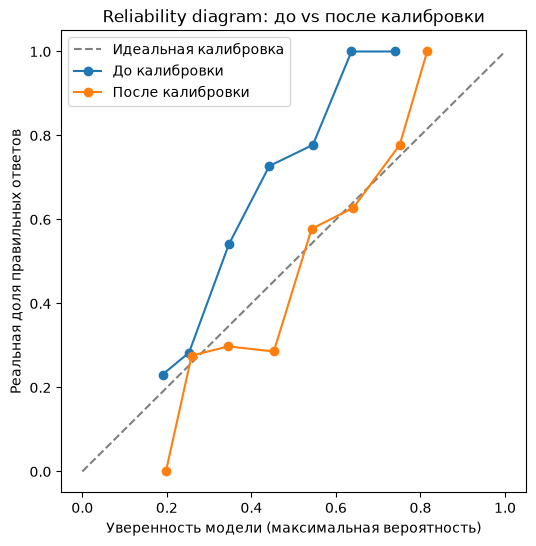

In [4]:
def reliability_diagram(y_true, y_proba, classes, n_bins=10):
    classes = np.array(classes)
    confidences = y_proba.max(axis=1)
    predictions = classes[y_proba.argmax(axis=1)]
    correct = (predictions == y_true.to_numpy())

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_confidence, bin_accuracy, bin_count = [], [], []

    for i in range(n_bins):
        mask = (confidences > bin_edges[i]) & (confidences <= bin_edges[i + 1])
        if mask.sum() > 0:
            bin_confidence.append(confidences[mask].mean())
            bin_accuracy.append(correct[mask].mean())
            bin_count.append(mask.sum())

    return np.array(bin_confidence), np.array(bin_accuracy), np.array(bin_count)


conf_before, acc_before, _ = reliability_diagram(y_test, proba_before, classes)
conf_after, acc_after, _ = reliability_diagram(y_test, proba_after, classes)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Идеальная калибровка")
ax.plot(conf_before, acc_before, marker="o", label="До калибровки")
ax.plot(conf_after, acc_after, marker="o", label="После калибровки")
ax.set_xlabel("Уверенность модели (максимальная вероятность)")
ax.set_ylabel("Реальная доля правильных ответов")
ax.set_title("Reliability diagram: до vs после калибровки")
ax.legend()
plt.show()

## 4. Confusion matrix лучшей модели

Confusion matrix (матрица ошибок) показывает, какие эмоции модель путает
между собой чаще всего: по строкам — реальная эмоция, по столбцам — что
предсказала модель. Диагональ — правильные ответы, всё вне диагонали —
ошибки.

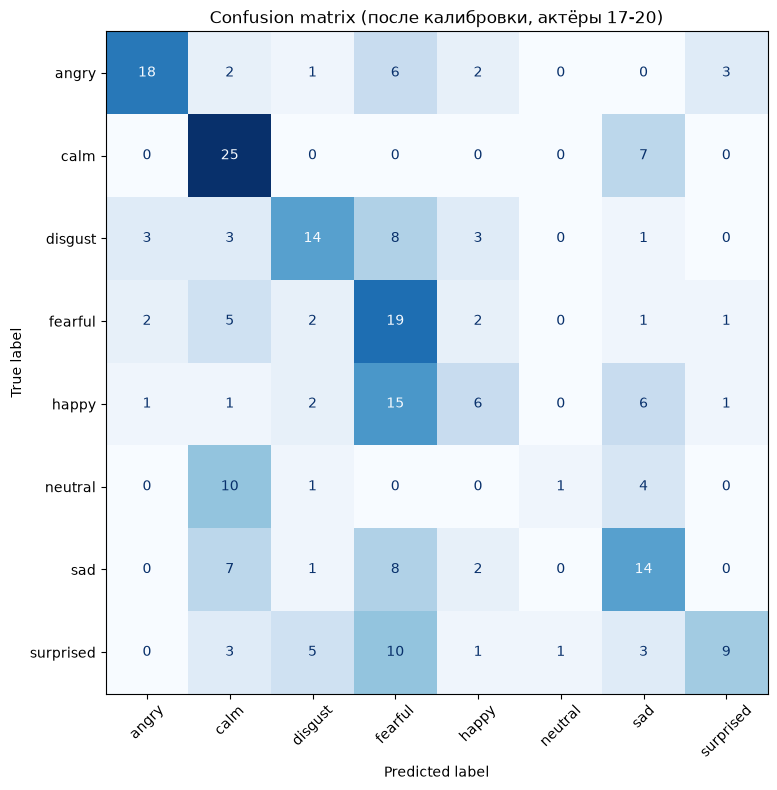

In [5]:
cm = confusion_matrix(y_test, pred_after, labels=classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (после калибровки, актёры 17-20)")
plt.tight_layout()
plt.show()

## 5. Вывод

*(допиши своими словами, опираясь на таблицу и графики выше)*

Примерные вопросы, на которые стоит ответить:
- Улучшился ли Log Loss / Brier Score после калибровки?
- Изменились ли Accuracy и Macro F1, и почему это ожидаемо (или нет)?
- Что видно на reliability diagram — стала ли модель ближе к диагонали
  после калибровки, или нет?
- Какие эмоции модель путает сильнее всего (по confusion matrix)?
- Итоговый вывод: помогла ли посткалибровка вероятностей в этом проекте?